# Explicite Finate Difference

In [28]:
from enum import Enum
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

In [29]:
class OptionBasicType(Enum):
	CALL = "CALL"
	PUT = "PUT"
	
class OptionExerciseType(Enum):
	EUROPEAN = "EUROPEAN"
	AMERICAN = "AMERICAN"

In [30]:
class EFD():
    def __init__(
        self,
        sigma_min: float,
        sigma_max: float,
        option_basic_type: OptionBasicType,
        option_exercise_type: OptionExerciseType,
        expiry_date: datetime,
        T0: datetime,
        strike_price: float,
        barrier_price: float = None,
        r: float = 0.0,

        delta_t: float = 0.01, # in year
        delta_s: float = 0.01,

        dividend_yield: float = 0.0,
        dividend_date: datetime = None,

        verbose: bool = True,

    ) -> None:
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        self.option_basic_type = option_basic_type
        self.option_exercise_type = option_exercise_type
        self.expiry_date = expiry_date
        self.T0 = T0
        self.strike_price = strike_price
        self.barrier_price = barrier_price
        self.r = r

        self.delta_t = delta_t
        self.delta_s = delta_s

        self.dividend_yield = dividend_yield
        self.dividend_date = dividend_date

        self.verbose = verbose
        
        self.initialize_grid()

    def payoff(self, S):
        if self.option_basic_type == OptionBasicType.CALL:
            return np.maximum(S - self.strike_price, 0)
        elif self.option_basic_type == OptionBasicType.PUT:
            return np.maximum(self.strike_price - S, 0)
        else:
            raise ValueError("Invalid option basic type")


    # S(underlying price) = i * delta_s is in comlumn. When i=0 then the price is 0, when i=N then the price is N*delta_s.
    # t(time) = j * delta_t is in row. When j=0 then the time is expiry date, when j=M then the time is T0.
    def initialize_grid(self):
        if self.barrier_price is None:
            self.N = int(3 * self.strike_price / self.delta_s)
        else:
            self.N = int(self.barrier_price / self.delta_s)
        self.M = int((self.expiry_date - self.T0).days / 365 / self.delta_t)
        self.grid = np.zeros((self.N + 1, self.M + 1))

        if self.verbose:
            print(f"Initialized grid with shape: {self.grid.shape}")

        # Right boudary condition for expired option, when time is 0, the option value is the payoff.
        self.grid[:, 0] = self.payoff(np.arange(self.N + 1) * self.delta_s)

        # Left boundary condition for underlying price is 0, the option value is 0.
        self.grid[0, :] = 0.0

        if self.barrier_price is None:
            raise NotImplementedError("Option with no barrier is not implemented yet")
        else:
            # Upper boundary condition for underlying price is barrier price, the option value is 0.
            self.grid[self.N, :] = 0.0

    
    def calculate_grid(self):
        i_arr = np.arange(1, self.N)        

        for j in range(1,self.M + 1):
            # We calculate using numpy array, so we can calculate the whole column at once.

            prev_col = self.grid[:, j - 1]
            gamma = (prev_col[2:] - 2 * prev_col[1:-1] + prev_col[:-2]) / (self.delta_s ** 2)

            # We use worst case scenario sigma
            sigma = np.where(gamma > 0, self.sigma_max, self.sigma_min)

            p_u = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r * i_arr)
            p_m = 1 - self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r)
            p_d = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) - self.r * i_arr)

            self.grid[1:-1,j] = p_u * prev_col[2:] + p_m * prev_col[1:-1] + p_d * prev_col[:-2]

            if self.option_exercise_type == OptionExerciseType.AMERICAN:
                self.grid[1:-1,j] = np.maximum(self.grid[1:-1,j], self.payoff(i_arr * self.delta_s))

    def get_option_price(self, S0):
        i = int(S0 / self.delta_s)
        j = self.M
        if i > self.N or j > self.M:
            raise ValueError("S0 is out of grid range")
        return self.grid[i, j]
    
    def get_option_prices_T0(self):
        return self.grid[:, -1]
    


In [31]:
efd = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.EUROPEAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    
    delta_t=1/(365 * 100),
    delta_s=10,

    dividend_yield=300,
    dividend_date=datetime(2026, 6, 1),

    verbose=True
)

efd.calculate_grid()
option_prices = efd.get_option_prices_T0()

Initialized grid with shape: (361, 36401)


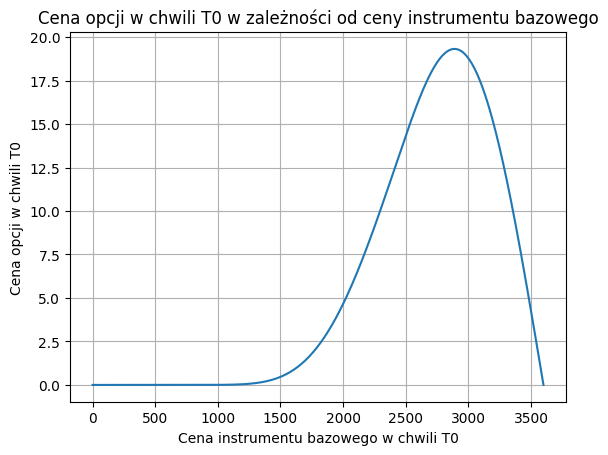

In [32]:
X = np.arange(efd.N + 1) * efd.delta_s
plt.plot(X, option_prices)
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.title("Cena opcji w chwili T0 w zależności od ceny instrumentu bazowego")
plt.grid()
plt.show()